# Citation
The dataset `Wisconsin Breast Cancer Dataset (WBCD)` utilized in this notebook is retrieved from `scikit-learn`'s datasets package.

## 1. Importing Libraries
We start our analysis by importing essential packages and libraries.

In [1]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.datasets import load_breast_cancer

## 2. Loading Data
First, get the target and feature names by extracting them from the dataset

In [2]:
# Get the target name and features
target_name = load_breast_cancer()['target_names']
features = load_breast_cancer()['feature_names']

print(f"Features: {features}\n\nTarget: {target_name}")

Features: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Target: ['malignant' 'benign']


Convert the whole data into two separate dataframes for  further analysis, i.e., `target` and `features` (denoted as `data`)

In [3]:
# Convert data and target to the pandas dataframe
cancer = load_breast_cancer()
df = pd.DataFrame(cancer['data'], columns=cancer['feature_names'])
df['target'] = cancer['target']
df.to_csv('breast_cancer.csv', index=False)
data = pd.read_csv('breast_cancer.csv')

In [4]:
# Get the first few rows of features
data.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [5]:
# Display target
data['target'].tail()

564    0
565    0
566    0
567    0
568    1
Name: target, dtype: int64

**NOTE:** `0` corresponds to `malignant`, and `1` corresponds to `benign`.

## 3. Data Analysis

In [6]:
# Display class imbalance
print(data['target'].value_counts(normalize=True))

target
1    0.627417
0    0.372583
Name: proportion, dtype: float64


So there's obviously a class imbalance in the target column. Class `Benign` has more samples than `Malignant` class (a ratio of 0.63 against 0.32). This matter should be taken into consideration when building the classification model.

Let's check for duplicates and `nan` values

In [7]:
# Check for duplicates and NANs
print(
    f'Total number of duplicated records: {data.duplicated().sum()}\n\n'
    f'Total number of NANs among columns:\n\n{data.isna().sum()}'
)


Total number of duplicated records: 0

Total number of NANs among columns:

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64


In [8]:
# Get basic information
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

## 4. Data Visualization
Since there exists neither duplicates nor NaNs, let's move to the visualization section.
We begin by understanding the relationship between features-features and features-target. This relationship is known as `correlation`. With the help of this measure, we'll be able to extract the two most correlated features which will further improve the inference phase (making prediction) by producing more accurate weights and biases (parameters).
The relationship between features is known as `multicollinearity` and shows how two features affect each other.
On the other hand, the relationship between features and the target can be measured by a quantity called `pearson correlation` which shows the amount of change of the target variable by the change of the features in some units.

### 4.1 Heatmap
The correlation can be plotted using `heatmap` from the `seaborn` library. Let's examine whether there exists `Multicollinearity`.

#### 4.1.1 Multicollinearity

In [9]:
# Get the columns 
data.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'target'],
      dtype='str')

In [10]:
# Store the features
features = [col for col in data.columns if col != "target"]

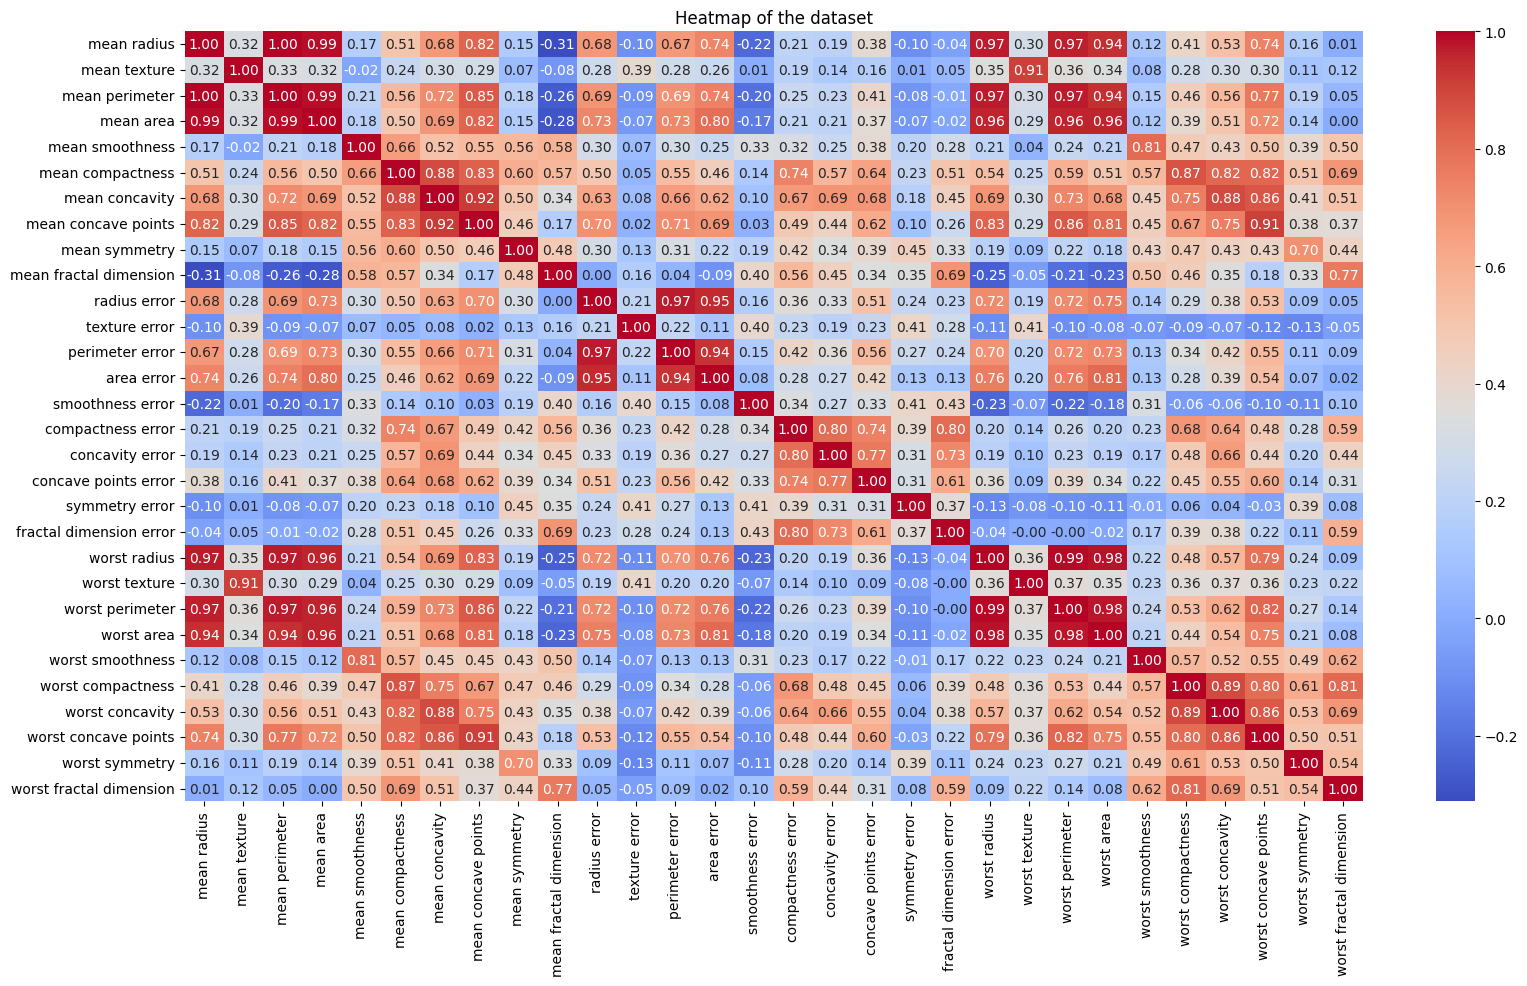

In [11]:
# Create a heatmap to visualize how correlated variables are
plt.figure(figsize=(19, 10))

sns.heatmap(data[['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension']].corr(numeric_only=True), 
            annot=True, fmt='.2f', cmap='coolwarm')

plt.title('Heatmap of the dataset')
plt.show()

As we observe, the correlation between features that are all almost duplicates of each other is above 0.9. We should look for the features that have a low correlation which each other (low multicollinearity), and a strong pearson correlation with the target.

#### 4.1.2 Pearson Correlation

                    Feature  Pearson_corr
0               mean radius     -0.730029
1              mean texture     -0.415185
2            mean perimeter     -0.742636
3                 mean area     -0.708984
4           mean smoothness     -0.358560
5          mean compactness     -0.596534
6            mean concavity     -0.696360
7       mean concave points     -0.776614
8             mean symmetry     -0.330499
9    mean fractal dimension      0.012838
10             radius error     -0.567134
11            texture error      0.008303
12          perimeter error     -0.556141
13               area error     -0.548236
14         smoothness error      0.067016
15        compactness error     -0.292999
16          concavity error     -0.253730
17     concave points error     -0.408042
18           symmetry error      0.006522
19  fractal dimension error     -0.077972
20             worst radius     -0.776454
21            worst texture     -0.456903
22          worst perimeter     -0

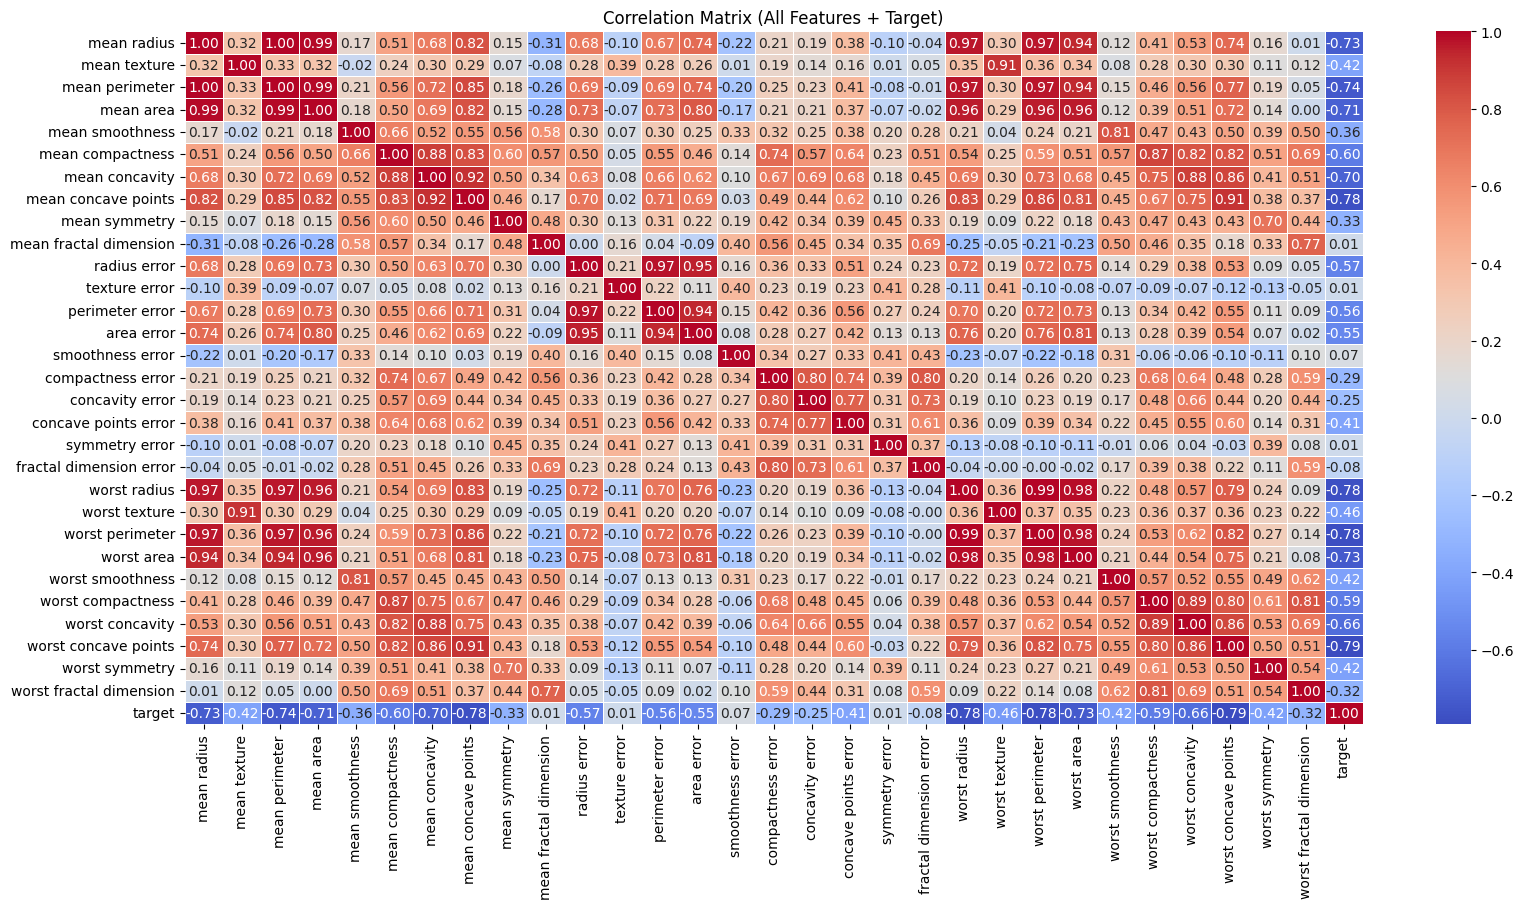

In [12]:
# Compute the correlation between each feature and the target
pearson_corr = []

for col in features:
    pc, _ = pearsonr(data[col], data['target'])
    pearson_corr.append(pc)

corr_df = pd.DataFrame({
    'Feature': features,
    'Pearson_corr': pearson_corr
})
print(corr_df)

full_corr = data.corr()

# Check correlation of each feature with the target
feature_target_corr = full_corr['target'].drop('target')  # exclude self-correlation

plt.figure(figsize=(19, 9))
sns.heatmap(full_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix (All Features + Target)')
plt.show()

### 4.2 Feature-Pair Scoring
Choosing the two most correlated features using the Heatmap alone would be a difficult choice. To make sure the selected features are scientifically reasonable, we would use the feature-pair scoring method, which helps to explain a report and penalize multicollinearity.

The formula is provided below:

$score=|corr(A,y)|×|corr(B,y)|×(1−∣corr(A,B)∣)$

Where:

- corr(A,y): correlation between feature A and target
- corr(B,y): correlation between feature B and target
- corr(A,B): correlation between the two features
- λ: penalty strength for redundancy

In [13]:
# Filter the valid features by only choosing those with a correlation of above 0.4
valid_features = []

for feature in features:
    corr = abs(data[feature].corr(data['target']))

    if corr > 0.4:
        valid_features.append(feature)

In [14]:
# Compute the feature-pair scoring for each pair of the features and save it in a dataframe 
lambda_penalty = 1.0

results = []

for f1, f2 in itertools.combinations(valid_features, 2):

    corr_f1_target = abs(data[f1].corr(data['target']))
    corr_f2_target = abs(data[f2].corr(data['target']))
    corr_between = abs(data[f1].corr(data[f2]))

    score = (
        corr_f1_target * corr_f2_target * (1 - corr_between)
    )

    results.append({
        'feature_1': f1,
        'feature_2': f2,
        'target_corr_1': corr_f1_target,
        'target_corr_2': corr_f2_target,
        'feature_corr': corr_between,
        'score': score
    })

results_df = pd.DataFrame(results)

top_pairs = results_df.sort_values(
    by='score',
    ascending=False
)

print(top_pairs.head(15))

               feature_1          feature_2  target_corr_1  target_corr_2  \
14           mean radius   worst smoothness       0.730029       0.421465   
49        mean perimeter   worst smoothness       0.742636       0.421465   
65             mean area   worst smoothness       0.708984       0.421465   
157         worst radius   worst smoothness       0.776454       0.421465   
66             mean area  worst compactness       0.708984       0.590998   
18           mean radius     worst symmetry       0.730029       0.416294   
15           mean radius  worst compactness       0.730029       0.590998   
69             mean area     worst symmetry       0.708984       0.416294   
170      worst perimeter   worst smoothness       0.782914       0.421465   
104  mean concave points      worst texture       0.776614       0.456903   
53        mean perimeter     worst symmetry       0.742636       0.416294   
175           worst area   worst smoothness       0.733825       0.421465   

Based on the output above, higher scores indicate better feature pairs for selection. `mean radius` & `worst smoothness`can be considered as the selected features.

### 4.3 Champion Features
Plot the `regplot` between features pair.

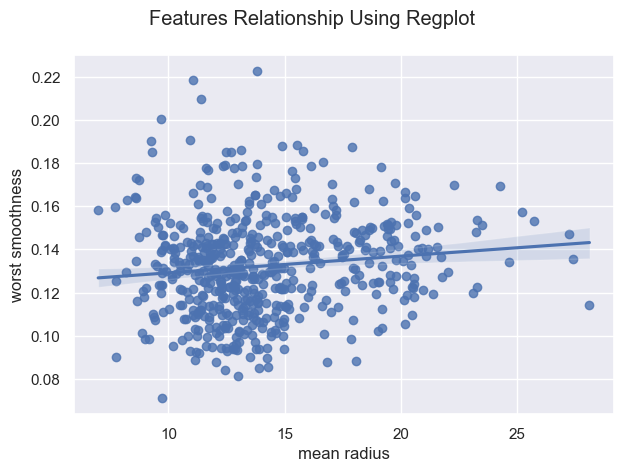

In [15]:
# Show the relationship among features using regplot
sns.set_theme(style='darkgrid')
plt.suptitle('Features Relationship Using Regplot')

sns.regplot(x=data['mean radius'], y=data['worst smoothness'])

plt.tight_layout()
plt.show();

The regplot, which stands for regression plot shows the relationship between our two variables, the features. As we can observe, the data is spread and the line between these two features does not have a sharp positive slope. Meaning the two variables wouldn't drastically change with teh amount of the change of the other variable.

In [16]:
# Compute the correlation between the two pair of features
print(data[['mean radius', 'worst smoothness']].corr())

                  mean radius  worst smoothness
mean radius          1.000000          0.119616
worst smoothness     0.119616          1.000000


### 4.4 Barplot

In [17]:
# Get the labels
labels = np.where(data['target'] == 0, 'malignant', 'benign')

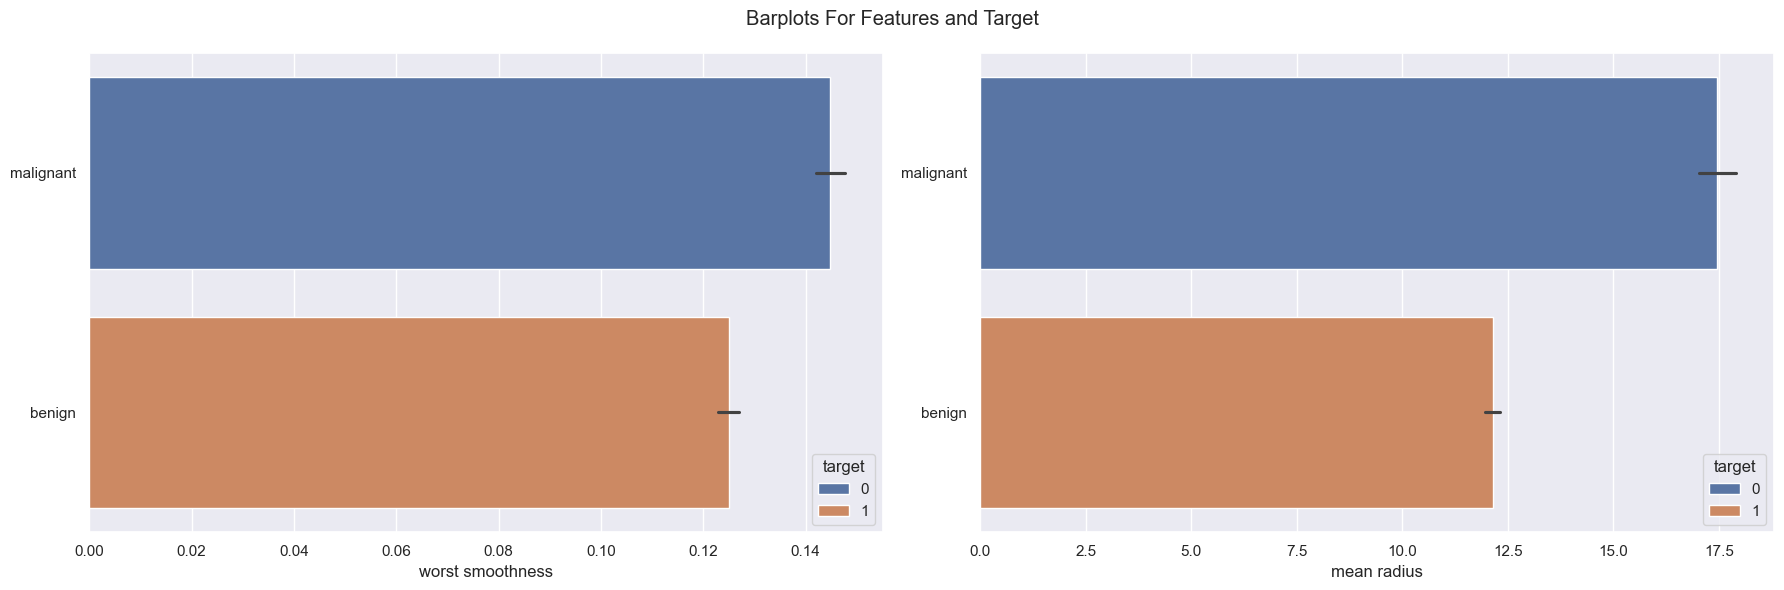

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Barplots For Features and Target')

sns.barplot(x=data['worst smoothness'], y=labels, hue=data['target'], ax=axes[0])
sns.barplot(x=data['mean radius'], y=labels, hue=data['target'], ax=axes[1])

plt.tight_layout()
plt.show()

The `barplot` obviously shows the class imbalance that should be handled before any model implementation process.
Let's display a discriptive summary of the features.

### 4.5 Boxplot
Let's detect the outliers of the features and impute them if needed.

In [19]:
# Get a basic descriptive analysis
selected_features = data[['worst smoothness', 'mean radius']]
selected_features.describe()

,worst smoothness,mean radius
count,569.000000,569.000000
mean,0.132369,14.127292
std,0.022832,3.524049
min,0.071170,6.981000
25%,0.116600,11.700000
50%,0.131300,13.370000
75%,0.146000,15.780000
max,0.222600,28.110000


In [20]:
# Function to display boxplots for detecting outliers of the selected features' columns
def display_boxplot(column1, column2):

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle('Boxplot for detecting outliers')
    
    sns.boxplot(x=selected_features[column1], ax=axes[0])
    axes[0].set_xlabel(column1)
    axes[0].set_ylabel('distribution')
        
    sns.boxplot(x=selected_features[column2], ax=axes[1])
    axes[1].set_xlabel(column2)
    axes[1].set_ylabel('distribution')
    
    plt.tight_layout()
    plt.show()    

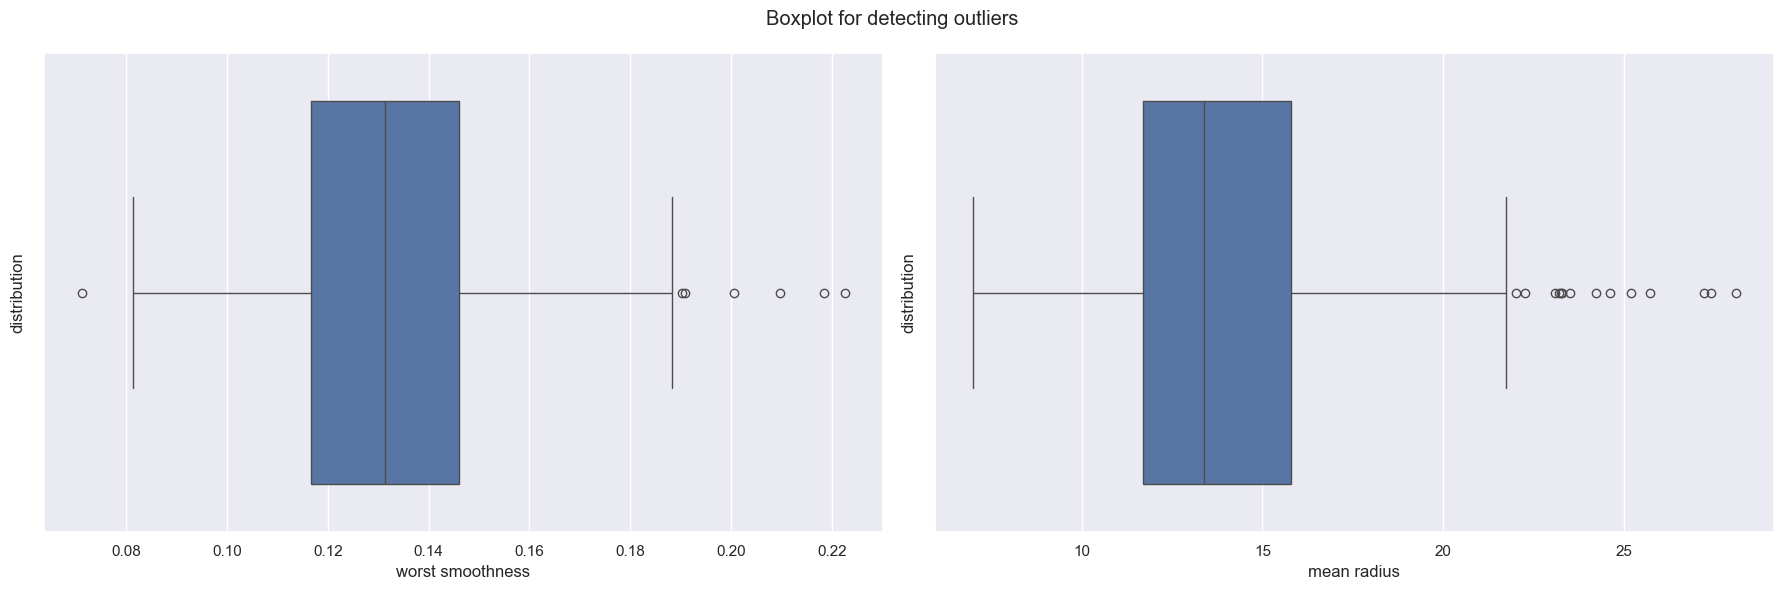

In [21]:
display_boxplot('worst smoothness', 'mean radius')

In [22]:
# Convert the selected features array to pandas dataframe
final_data = pd.DataFrame(selected_features, columns=selected_features.columns)

# Add the target to the dataset
final_data['target'] = data['target']

In [23]:
# Save the dataset as the training data for training the network
final_data.to_csv('breast_cancer.csv', index=False)

In the next notebook, we'll move on to the implementation phase, where we'll be building the neural network and train it using the final version of the dataset.